Oxygen limited? True
Final values:
X = 17.755260275416525 g/L
S = 0.40789957303935515 g/L
CL = 0.04702750835126271 mg/L
CG = 240.5424338092917 mg/L


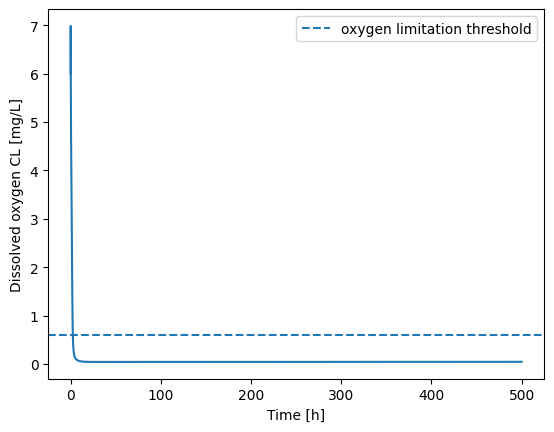

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


mu_m = 0.9      
K_s = 0.21      
K_I = 15        
Y_XS = 0.6      
K_CL = 0.2   
Y_OS = 160     
M = 0.0314
V_L = 90       
G = 5000       
eps = 0.2
C_Li = 6        
C_Gi = 250      
S_i = 30       

V_G = eps * V_L


y0 = [1, 0, 6, 250]

def mu(S, CL):
    return mu_m * S / (K_s + S + S**2 / K_I) * CL / (K_CL + CL)

def system(t, y, F, KLa):
    X, S, CL, CG = y

    growth = mu(S, CL)
    CL_star = M * CG

    dXdt = -(F / V_L) * X + growth * X

    dSdt = (F / V_L) * (S_i - S) - (1 / Y_XS) * growth * X

    dCLdt = (
        (F / V_L) * (C_Li - CL)
        - (Y_OS / Y_XS) * growth * X
        + KLa * (CL_star - CL)
    )

    dCGdt = (
        (G / V_G) * (C_Gi - CG)
        - KLa * (V_L / V_G) * (CL_star - CL)
    )

    return [dXdt, dSdt, dCLdt, dCGdt]

def simulate(F, KLa, t_end=500):
    sol = solve_ivp(
        system,
        [0, t_end],
        y0,
        args=(F, KLa),
        method="BDF",
        rtol=1e-6,
        atol=1e-6
    )
    return sol

def is_oxygen_limited(sol):
    CL = sol.y[2]
    return np.any(CL <= 3 * K_CL)


F = 10
KLa = 70

sol = simulate(F, KLa)

print("Oxygen limited?", is_oxygen_limited(sol))
print("Final values:")
print("X =", sol.y[0, -1], "g/L")
print("S =", sol.y[1, -1], "g/L")
print("CL =", sol.y[2, -1], "mg/L")
print("CG =", sol.y[3, -1], "mg/L")

plt.plot(sol.t, sol.y[2])
plt.axhline(3 * K_CL, linestyle="--", label="oxygen limitation threshold")
plt.xlabel("Time [h]")
plt.ylabel("Dissolved oxygen CL [mg/L]")
plt.legend()
plt.show()

In [3]:
F_values = np.linspace(6.5, 10, 8)
KLa_values = np.linspace(1, 300, 300)

results = {}

for F in F_values:
    for KLa in KLa_values:
        sol = simulate(F, KLa)
        if not is_oxygen_limited(sol):
            results[F] = KLa
            break

print(results)

{6.5: 62.0, 7.0: 69.0, 7.5: 75.0, 8.0: 83.0, 8.5: 90.0, 9.0: 98.0, 9.5: 106.0, 10.0: 115.0}


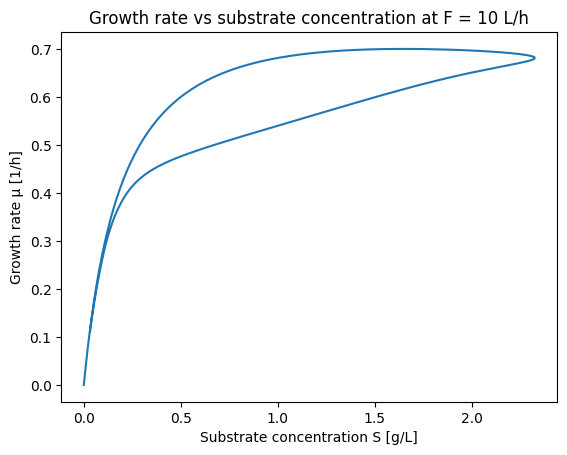

In [4]:
F = 10
KLa = results[F]

sol = simulate(F, KLa)

X = sol.y[0]
S = sol.y[1]
CL = sol.y[2]

growth_rate = mu(S, CL)

plt.plot(S, growth_rate)
plt.xlabel("Substrate concentration S [g/L]")
plt.ylabel("Growth rate μ [1/h]")
plt.title("Growth rate vs substrate concentration at F = 10 L/h")
plt.show()

***b)***

In [ ]:
F = 0
KLa = 70
y0_batch = [1, 30, 6, 250]   

In [6]:
def simulate_batch(t_end=100):
    sol = solve_ivp(
        system,
        [0, t_end],
        y0_batch,
        args=(0, 70),
        method="BDF",
        rtol=1e-6,
        atol=1e-6
    )
    return sol

sol = simulate_batch()

t = sol.t
X = sol.y[0]
S = sol.y[1]
CL = sol.y[2]
CG = sol.y[3]

growth_rate = mu(S, CL)

OUR = (Y_OS / Y_XS) * growth_rate * X * V_L

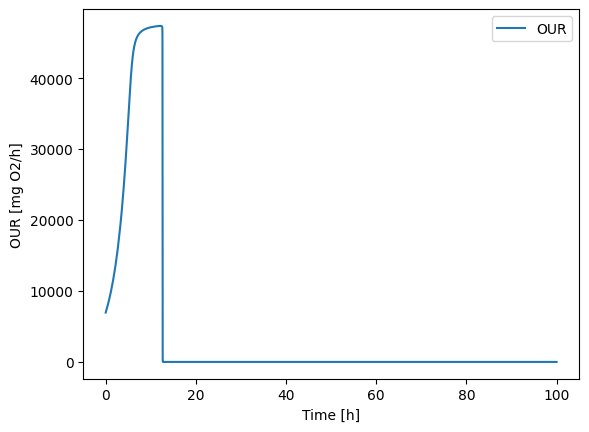

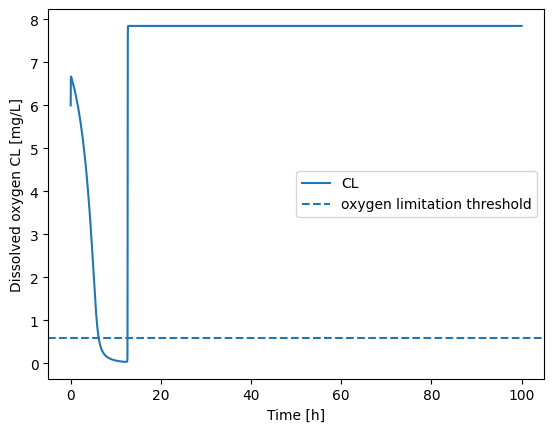

In [7]:
plt.figure()
plt.plot(t, OUR, label="OUR")
plt.xlabel("Time [h]")
plt.ylabel("OUR [mg O2/h]")
plt.legend()
plt.show()

plt.figure()
plt.plot(t, CL, label="CL")
plt.axhline(3 * K_CL, linestyle="--", label="oxygen limitation threshold")
plt.xlabel("Time [h]")
plt.ylabel("Dissolved oxygen CL [mg/L]")
plt.legend()
plt.show()

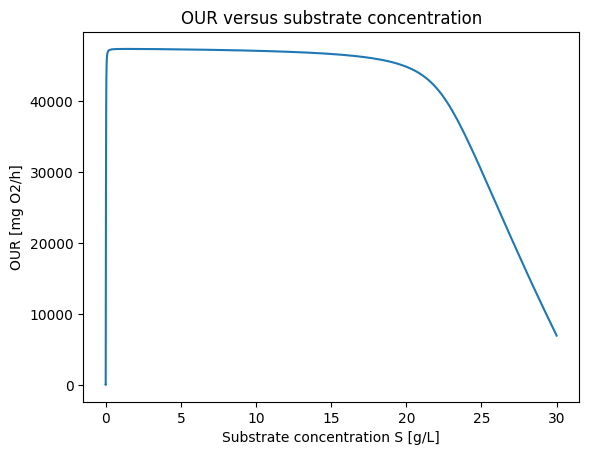

In [8]:
plt.figure()
plt.plot(S, OUR)
plt.xlabel("Substrate concentration S [g/L]")
plt.ylabel("OUR [mg O2/h]")
plt.title("OUR versus substrate concentration")
plt.show()

In [9]:
print("Minimum CL:", np.min(CL))
print("Threshold:", 3 * K_CL)
print("Oxygen limited?", np.any(CL <= 3 * K_CL))

Minimum CL: 0.03532848557354599
Threshold: 0.6000000000000001
Oxygen limited? True


***c)***

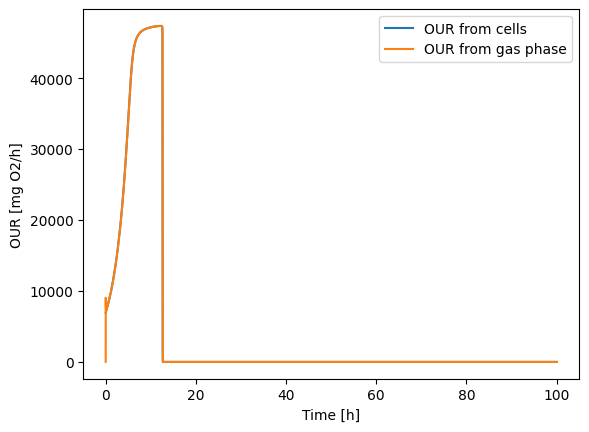

In [10]:
OUR_cells = (Y_OS / Y_XS) * growth_rate * X * V_L
OUR_gas = G * (C_Gi - CG)

plt.figure()
plt.plot(t, OUR_cells, label="OUR from cells")
plt.plot(t, OUR_gas, label="OUR from gas phase")
plt.xlabel("Time [h]")
plt.ylabel("OUR [mg O2/h]")
plt.legend()
plt.show()

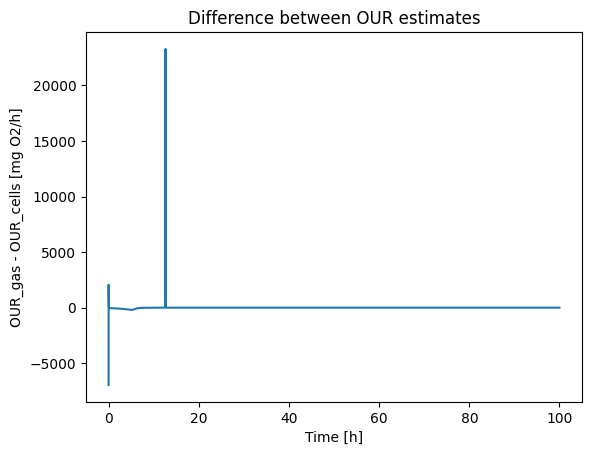

Mean absolute difference: 2712.0089327978467
Maximum absolute difference: 23285.764212144102


In [11]:
difference = OUR_gas - OUR_cells

plt.figure()
plt.plot(t, difference)
plt.xlabel("Time [h]")
plt.ylabel("OUR_gas - OUR_cells [mg O2/h]")
plt.title("Difference between OUR estimates")
plt.show()

print("Mean absolute difference:", np.mean(np.abs(difference)))
print("Maximum absolute difference:", np.max(np.abs(difference)))

***d)***

In [12]:
F = 6.5
KLa = 70
S_initial = 0

In [13]:
S_i = 30
S_i = 100

In [14]:
def system_cstr(t, y, F, KLa, S_feed):
    X, S, CL, CG = y

    growth = mu(S, CL)
    CL_star = M * CG

    dXdt = -(F / V_L) * X + growth * X

    dSdt = (F / V_L) * (S_feed - S) - (1 / Y_XS) * growth * X

    dCLdt = (
        (F / V_L) * (C_Li - CL)
        - (Y_OS / Y_XS) * growth * X
        + KLa * (CL_star - CL)
    )

    dCGdt = (
        (G / V_G) * (C_Gi - CG)
        - KLa * (V_L / V_G) * (CL_star - CL)
    )

    return [dXdt, dSdt, dCLdt, dCGdt]

In [15]:
def simulate_cstr(S_feed, t_end=500):
    y0 = [1, 0, 6, 250]   # X, S, CL, CG

    sol = solve_ivp(
        system_cstr,
        [0, t_end],
        y0,
        args=(6.5, 70, S_feed),
        method="BDF",
        rtol=1e-6,
        atol=1e-6
    )

    return sol

sol_30 = simulate_cstr(30)
sol_100 = simulate_cstr(100)

In [16]:
def get_OUR(sol):
    X = sol.y[0]
    S = sol.y[1]
    CL = sol.y[2]

    growth_rate = mu(S, CL)
    OUR = (Y_OS / Y_XS) * growth_rate * X * V_L

    return OUR, CL

OUR_30, CL_30 = get_OUR(sol_30)
OUR_100, CL_100 = get_OUR(sol_100)

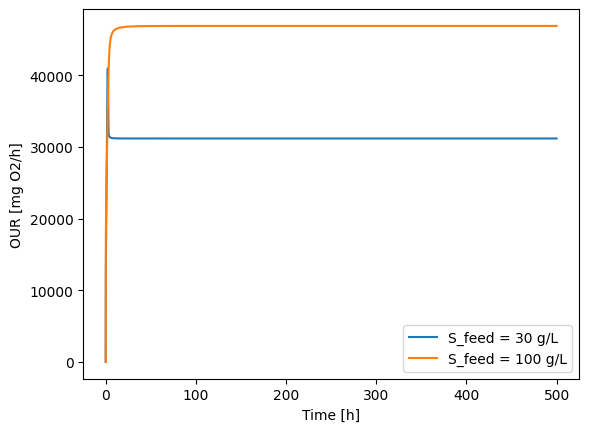

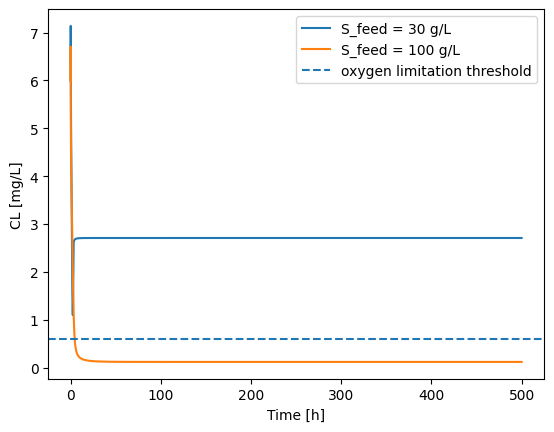

In [17]:
plt.figure()
plt.plot(sol_30.t, OUR_30, label="S_feed = 30 g/L")
plt.plot(sol_100.t, OUR_100, label="S_feed = 100 g/L")
plt.xlabel("Time [h]")
plt.ylabel("OUR [mg O2/h]")
plt.legend()
plt.show()

plt.figure()
plt.plot(sol_30.t, CL_30, label="S_feed = 30 g/L")
plt.plot(sol_100.t, CL_100, label="S_feed = 100 g/L")
plt.axhline(3 * K_CL, linestyle="--", label="oxygen limitation threshold")
plt.xlabel("Time [h]")
plt.ylabel("CL [mg/L]")
plt.legend()
plt.show()

In [18]:
print("30 g/L feed:")
print("Final OUR:", OUR_30[-1])
print("Final CL:", CL_30[-1])
print("Minimum CL:", np.min(CL_30))

print("100 g/L feed:")
print("Final OUR:", OUR_100[-1])
print("Final CL:", CL_100[-1])
print("Minimum CL:", np.min(CL_100))

30 g/L feed:
Final OUR: 31179.402730845093
Final CL: 2.7086120371962217
Minimum CL: 1.097416964988135
100 g/L feed:
Final OUR: 46885.83474452462
Final CL: 0.11966801434167335
Minimum CL: 0.11966801319028317
